In [1]:
# Core libraries for data manipulation
import pandas as pd
import numpy as np

# Libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Libraries for handling dates
import datetime as dt

# Settings for better display
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("viridis")

print("All libraries imported successfully.")

All libraries imported successfully.


In [2]:
# Define the path to your data folder
DATA_PATH = '../data/'  # Goes up one level from 'notebooks' folder
FILE_NAME = 'Dataset.csv'  # Adjust if your file has a different name (e.g., 'ecommerce_data.csv')

# Load the dataset
try:
    df = pd.read_csv(DATA_PATH + FILE_NAME, low_memory=False)
    print(f"Dataset loaded successfully. Shape: {df.shape}")
except FileNotFoundError:
    print(f"Error: File not found at '{DATA_PATH + FILE_NAME}'. Please check the path and file name.")

Dataset loaded successfully. Shape: (743486, 24)


In [3]:
# Create a copy to avoid modifying the original
df_clean = df.copy()

# 1. Handle dates: Convert InvoiceDate to datetime
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'], errors='coerce')

# 2. Remove rows without a Customer ID (essential for cohort analysis)
df_clean = df_clean.dropna(subset=['Customer ID'])

# 3. Remove cancelled orders (negative quantity)
df_clean = df_clean[df_clean['Quantity'] > 0]

# 4. Create 'Revenue' column if it doesn't exist
if 'Revenue' not in df_clean.columns:
    df_clean['Revenue'] = df_clean['Quantity'] * df_clean['Price']

print(f"Shape after initial cleaning: {df_clean.shape}")
df_clean.head()

Shape after initial cleaning: (559950, 24)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Customer_Age,Gender,Signup_Date,Last_Login_Date,Customer_Segment,Marketing_Channel,Category,Subcategory,Cost,Discount_Applied,Payment_Method,Promo_Applied,Delivery_Time_Days,Revenue,Profit,Churn_Flag
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,26.0,Female,2009-07-22 07:45:00,2009-10-04 07:45:00,Regular,Organic,Home Decor,Decor,4.469733,0,Credit Card,0,5,83.4,29.763202,0
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,29.0,Female,2008-08-23 07:45:00,2009-08-19 07:45:00,VIP,Referral,Toys,Kids,3.282128,0,PayPal,0,9,81.0,41.614466,1
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,33.0,Female,2009-02-04 07:45:00,2009-08-25 07:45:00,VIP,Organic,Kitchen,Appliances,4.612600,0,Cash,0,7,81.0,25.648799,1
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,79.0,Female,2009-07-18 07:45:00,2009-07-20 07:45:00,Regular,Referral,Clothing,Women,1.120376,0,Bank Transfer,0,8,100.8,47.021953,1
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,43.0,Female,2009-08-22 07:45:00,2009-11-12 07:45:00,New,Referral,Clothing,Men,0.848714,0,Cash,0,8,30.0,9.630864,0


In [4]:
# Function to get the first day of the month from a date
def get_month(x):
    return dt.datetime(x.year, x.month, 1)

# Create 'InvoiceMonth' column
df_clean['InvoiceMonth'] = df_clean['InvoiceDate'].apply(get_month)

# Group by Customer ID and find the first purchase month (cohort)
grouping = df_clean.groupby('Customer ID')['InvoiceMonth']
df_clean['CohortMonth'] = grouping.transform('min')

# Extract year and month for InvoiceMonth and CohortMonth
def get_date_elements(df, column):
    year = df[column].dt.year
    month = df[column].dt.month
    return year, month

invoice_year, invoice_month = get_date_elements(df_clean, 'InvoiceMonth')
cohort_year, cohort_month = get_date_elements(df_clean, 'CohortMonth')

# Calculate the difference in months
year_diff = invoice_year - cohort_year
month_diff = invoice_month - cohort_month
df_clean['CohortIndex'] = year_diff * 12 + month_diff + 1

print("Cohorts created. First rows:")
df_clean[['Customer ID', 'InvoiceMonth', 'CohortMonth', 'CohortIndex']].head()

Cohorts created. First rows:


,Customer ID,InvoiceMonth,CohortMonth,CohortIndex
0,13085.0,2009-12-01,2009-12-01,1
1,13085.0,2009-12-01,2009-12-01,1
2,13085.0,2009-12-01,2009-12-01,1
3,13085.0,2009-12-01,2009-12-01,1
4,13085.0,2009-12-01,2009-12-01,1


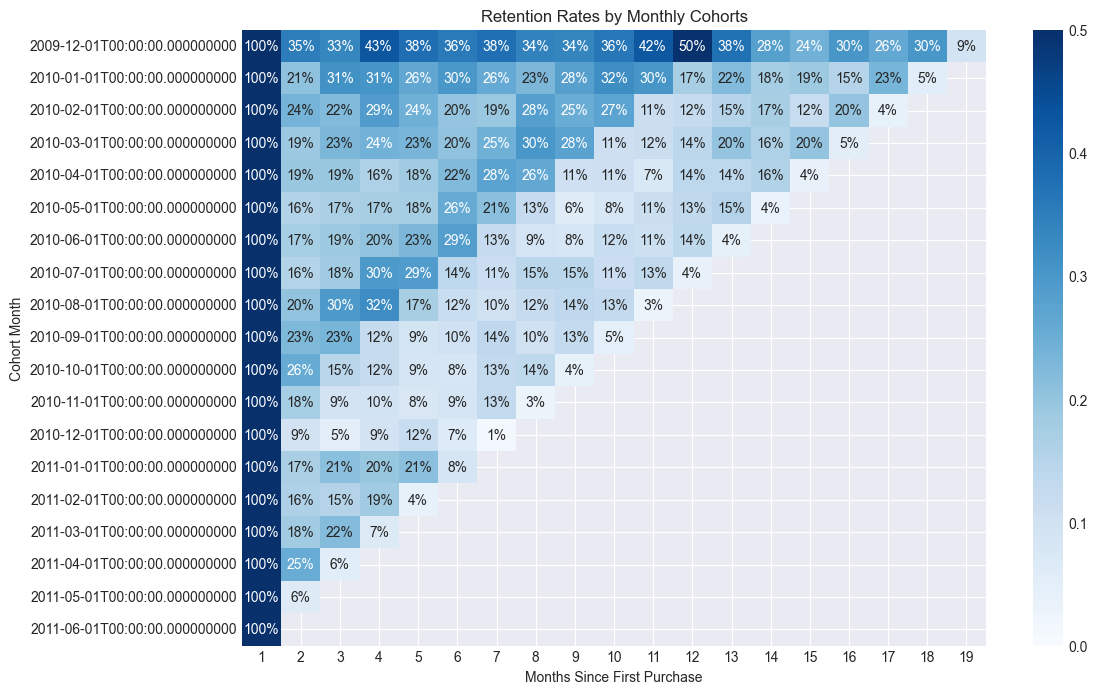

In [5]:
# Group by CohortMonth and CohortIndex to count unique customers
cohort_data = df_clean.groupby(['CohortMonth', 'CohortIndex'])['Customer ID'].apply(pd.Series.nunique).reset_index()
cohort_counts = cohort_data.pivot(index='CohortMonth', columns='CohortIndex', values='Customer ID')

# Calculate retention rates
cohort_sizes = cohort_counts.iloc[:,0]
retention = cohort_counts.divide(cohort_sizes, axis=0)

# Visualize the retention matrix as a heatmap
plt.figure(figsize=(12, 8))
plt.title('Retention Rates by Monthly Cohorts')
sns.heatmap(retention, annot=True, fmt='.0%', cmap='Blues', vmin=0.0, vmax=0.5)
plt.ylabel('Cohort Month')
plt.xlabel('Months Since First Purchase')
plt.show()

In [6]:
# Group by Marketing Channel and calculate key metrics
channel_analysis = df_clean.groupby('Marketing_Channel').agg({
    'Customer ID': 'nunique',
    'Revenue': 'sum',
    'Quantity': 'sum'
}).rename(columns={'Customer ID': 'Unique Customers', 'Revenue': 'Total Revenue', 'Quantity': 'Total Items Sold'})

# Calculate average revenue per customer
channel_analysis['Avg Revenue per Customer'] = channel_analysis['Total Revenue'] / channel_analysis['Unique Customers']

# Sort by total revenue
channel_analysis = channel_analysis.sort_values('Total Revenue', ascending=False)

print("Analysis by Marketing Channel:")
channel_analysis

Analysis by Marketing Channel:


,Unique Customers,Total Revenue,Total Items Sold,Avg Revenue per Customer
Marketing_Channel,,,,
Referral,4748,3111683.631,1921810,655.367235
Email,4749,3086191.885,1887403,649.861420
Organic,4765,3059648.258,1908998,642.108763
Ads,4745,3051031.021,1839606,642.999161


In [7]:
# Save the cleaned dataset for later use
df_clean.to_csv(DATA_PATH + 'ecommerce_cleaned_for_cohorts.csv', index=False)
print("Cleaned data saved successfully to 'ecommerce_cleaned_for_cohorts.csv'.")

Cleaned data saved successfully to 'ecommerce_cleaned_for_cohorts.csv'.
